# Analisis dan Prediksi Harga Tiket Pesawat

**A. Background | B. Business Problem | C. Data and Data Source | D. Analysis and Modeling | E. Findings | F. Solutions and Recommendations**

Notebook ini dibuat untuk menjawab empat pertanyaan terkait harga pada pasar penerbangan domestik India dan membangun model machine learning (ML) yang memprediksi tarif dari atribut pemesanan. Setiap bagian menjelaskan prosesnya, menunjukkan fakta berdasarkan data, dan ditutup dengan insight yang sudah diverifikasi data.

## A. Background

Harga tiket pesawat sering berubah dalam hitungan jam dan hari tanpa penjelasan yang jelas. Sebagai contoh, harga sebuah kursi yang dicek pada hari Senin sebesar 6.000 INR dapat naik menjadi 16.000 INR pada hari Kamis. Perubahan ini memunculkan pertanyaan tentang faktor yang sebenarnya membentuk harga: maskapai, waktu keberangkatan, rute, atau waktu pembelian.

Keterbukaan data harga memungkinkan pertanyaan tersebut dijawab secara empiris. Analisis ini menggunakan 300.153 data pemesanan penerbangan domestik India untuk menguji setiap faktor pada transaksi nyata. Manfaatnya bersifat praktis. Jika pengaruh setiap faktor dapat diukur, harga dapat diprediksi. Penumpang dapat menghindari pembayaran berlebih, dan maskapai dapat menetapkan harga dengan lebih yakin.

Penelitian ini berpijak pada empat pertanyaan:

1. Apakah harga bervariasi menurut maskapai?
2. Apakah harga berubah menurut waktu keberangkatan dan waktu kedatangan?
3. Apakah harga berbeda menurut kota asal dan kota tujuan?
4. Apakah harga terpengaruh ketika tiket dibeli satu hingga dua hari sebelum keberangkatan?

## B. Business Probelm

Di sisi **Penumpang** melakukan pemesanan tanpa acuan harga yang jelas. Mereka menilai kewajaran tarif berdasarkan perkiraan, dan perkiraan tersebut dapat keliru ke dua arah. Pembelian yang terlalu dini berisiko melewatkan penurunan harga, sedangkan pembelian yang terlalu lambat dapat menambah biaya hingga ribuan INR untuk rute dan kelas kabin yang sama.

Sedangkan disisi **Maskapai dan platform pemesanan** menghadapi masalah yang sebaliknya. Mereka perlu mengetahui faktor yang benar-benar layak menjadi dasar kenaikan tarif. Tanpa bukti terukur, tim penetapan harga mengandalkan kebiasaan, misalnya menaikkan tarif penerbangan pagi karena dianggap wajar atau menurunkan tarif penerbangan tengah malam karena sudah menjadi praktik lama. Kebiasaan tersebut berpotensi menghilangkan pendapatan pada kedua sisi.

Penelitian ini menjawab kedua sisi permasalahan melalui dua tahap:

1. **Pengukuran faktor pendorong harga.** Penelitian mengkuantifikasi pengaruh maskapai, waktu keberangkatan dan kedatangan, rute, jumlah transit, durasi, kelas kabin, dan jendela pemesanan terhadap tarif. Faktor diurutkan menurut besar pengaruhnya agar yang paling dominan mendapat perhatian terlebih dahulu.
2. **Prediksi tarif.** Model regresi dibangun untuk memperkirakan harga berdasarkan atribut pemesanan. Model dengan galat prediksi sekitar 6% dari tarif aktual memberi penumpang harga acuan sebelum membeli, sekaligus memberi tim penetapan harga garis dasar untuk mengidentifikasi inventaris yang harganya tidak tepat.

Keberhasilan penelitian diukur dari dua hal: setiap pertanyaan penelitian memperoleh jawaban terukur yang didukung data, dan model mencapai nilai R² sebesar 0,985 sebagaimana tercantum dalam dokumentasi dataset.

## C. Data and Data Source

Dalam use case ini, data yang digunakan adalah `data/flight_dataset.csv` yang diunduh dari Kaggle (https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction), yaitu dataset publik pemesanan penerbangan domestik India.
**Ukuran.** Dataset terdiri dari 300.153 pemesanan dengan 11 kolom. Data tidak memiliki nilai kosong maupun baris duplikat, sehingga tidak memerlukan pembersihan sebelum dianalisis.

**Skema Data.**

| Kolom | Tipe | Deskripsi |
|---|---|---|
| `airline` | Kategorikal, 6 nilai | Maskapai (Vistara, Air_India, Indigo, GO_FIRST, SpiceJet, AirAsia) |
| `flight` | Kategorikal, 1.561 kode | Kode penerbangan, hanya berfungsi sebagai pengenal dan bukan sinyal prediktif |
| `source_city` | Kategorikal, 6 nilai | Kota keberangkatan |
| `departure_time` | Kategorikal, 6 bin | Bin waktu keberangkatan |
| `stops` | Kategorikal, 3 nilai | zero, one, two_or_more |
| `arrival_time` | Kategorikal, 6 bin | Bin waktu kedatangan |
| `destination_city` | Kategorikal, 6 nilai | Kota tujuan |
| `class` | Kategorikal, 2 nilai | Economy atau Business |
| `duration` | Kontinu | Total waktu tempuh dalam jam |
| `days_left` | Kontinu, rentang 1 sampai 49 | Selisih hari antara pemesanan dan keberangkatan |
| `price` | Kontinu | Harga tiket dalam INR (variabel target) |

**Keterbatasan.** Dataset tidak memuat tanggal kalender, sehingga pengaruh musiman tidak dapat dianalisis. Kemudian dari waktu keberangkatan dan kedatangan hanya tersedia dalam bentuk bin, bukan jam persis, sehingga resolusi analisis waktu menjadi terbatas. Selain itu, data hanya mencakup satu pasar, yaitu penerbangan domestik India, sehingga temuan tidak dapat digeneralisasi ke tarif internasional.

## D. Analysis and Modeling

Dalam notebook ini, analisis dibagi menjadi dua bagian. Bagian 1 menjawab empat pertanyaan harga dengan analisis eksplorasi, sedangkan bagian 2 fokus membangun model prediktif.
Karena harga condong ke kanan (right-skewed), semua perbandingan kelompok di Bagian 1 memakai **median**; Bagian 2 memodelkan `log1p(price)` dengan alasan yang sama.

### D.1 Import Data

In [1]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (11, 4)

df = pd.read_csv("data/flight_dataset.csv", index_col=0)
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head()

Rows: 300,153 | Columns: 11


,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


### D.2 Exploration Data Analysis (EDA) : Data Quality Check

Tahapan umum EDA dan permasalahan klasik yang sering muncul
1. Cek tipe data
2. Cek distribusi dan outlier
3. Cek missing values
4. Handling missing value, jika ada dapat menggunakan drop atau imputasi

In [2]:
print("=== Data types ===")
print(df.dtypes)
print(f"\nMissing values : {df.isna().sum().sum()}")
print(f"Duplicate rows : {df.duplicated().sum()}")

=== Data types ===
airline                 str
flight                  str
source_city             str
departure_time          str
stops                   str
arrival_time            str
destination_city        str
class                   str
duration            float64
days_left             int64
price                 int64
dtype: object

Missing values : 0
Duplicate rows : 0


Tidak ditemukan missing value dan data duplikat.

In [3]:
print("\n=== Categorical features ===")
for col in ["airline", "source_city", "departure_time", "stops",
            "arrival_time", "destination_city", "class"]:
    print(f"{col:17s} ({df[col].nunique()}): {sorted(df[col].unique())}")
print(f"{'flight':17s} ({df['flight'].nunique()} unique flight codes)")



=== Categorical features ===
airline           (6): ['AirAsia', 'Air_India', 'GO_FIRST', 'Indigo', 'SpiceJet', 'Vistara']
source_city       (6): ['Bangalore', 'Chennai', 'Delhi', 'Hyderabad', 'Kolkata', 'Mumbai']
departure_time    (6): ['Afternoon', 'Early_Morning', 'Evening', 'Late_Night', 'Morning', 'Night']
stops             (3): ['one', 'two_or_more', 'zero']
arrival_time      (6): ['Afternoon', 'Early_Morning', 'Evening', 'Late_Night', 'Morning', 'Night']
destination_city  (6): ['Bangalore', 'Chennai', 'Delhi', 'Hyderabad', 'Kolkata', 'Mumbai']
class             (2): ['Business', 'Economy']
flight            (1561 unique flight codes)


Seluruh kategori sesuai dengan skema data yang terdokumentasi. Dari info diatas, ada 2 kolom yang bertipe numerik yaitu: "duration", "days_left", "price".
Selanjutnya pengecekan statistik umum data numerik.

In [4]:

print("\n=== Numeric summary ===")
df[["duration", "days_left", "price"]].describe().T.round(2)


=== Numeric summary ===


,count,mean,std,min,25%,50%,75%,max
duration,300153.0,12.22,7.19,0.83,6.83,11.25,16.17,49.83
days_left,300153.0,26.00,13.56,1.00,15.00,26.00,38.00,49.00
price,300153.0,20889.66,22697.77,1105.00,4783.00,7425.00,42521.00,123071.00


**Insight:** Dataset berada dalam kondisi clean, ditemukan 300.153 baris data.
Harga tiket berkisar dari 1.105 hingga 123.071 INR, `days_left` dari 1 hingga 49 hari, dan durasi penerbangan dari 0,83 hingga 49,83 jam. 
Karena tidak diperlukan data cleansing, analisis dilanjutkan menggunakan data mentah. -> tidak perlu save as ke dataframe yang diberishkan.

### D.3 Distribusi Harga

Melihat distribusi harga, dilakuan dengan:
1. Membuat plot distribusi harga mentah.
2. Membuat plot distribusi harga setelah transformasi logaritma. -> biasanya dilakukan jika distribusi miring ke kanan, dengan tujuan membuat distribusi lebih simetris sehingga acuan nilai layak dipakai dan analisis lanjutan lebih valid.
3. Menghitung skewness pada kedua kondisi untuk memutuskan penggunaan mean atau median.

Hasil pengukuran skewness menentukan apakah mean atau median yang digunakan sebagai acuan harga (center price) dalam semua perbandingan dan analisis selanjutnya.

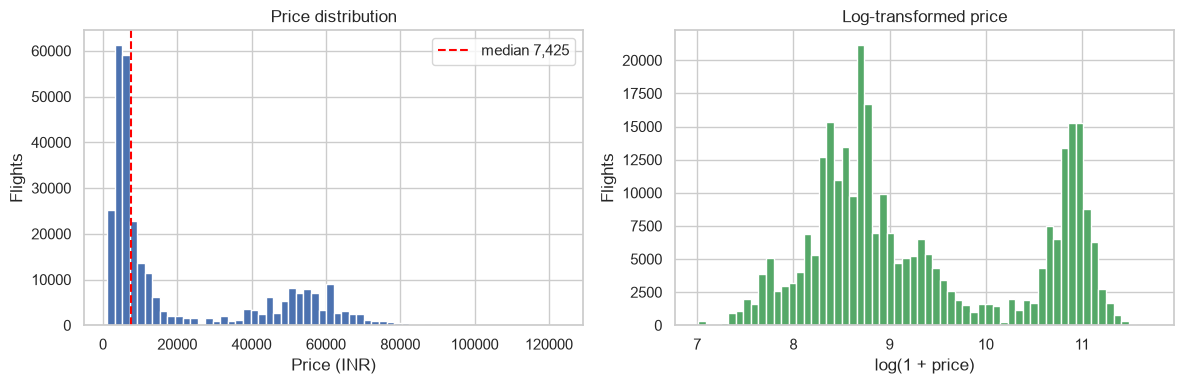

count    300153.0
mean      20890.0
std       22698.0
min        1105.0
25%        4783.0
50%        7425.0
75%       42521.0
max      123071.0
Skewness: 1.06


In [24]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(df["price"], bins=60, color="#4C72B0", edgecolor="white")
ax[0].axvline(df["price"].median(), color="red", ls="--",
              label=f"median {df['price'].median():,.0f}")
ax[0].set(title="Price distribution", xlabel="Price (INR)", ylabel="Flights")
ax[0].legend()

ax[1].hist(np.log1p(df["price"]), bins=60, color="#55A868", edgecolor="white")
ax[1].set(title="Log-transformed price", xlabel="log(1 + price)", ylabel="Flights")

plt.tight_layout(); plt.show()
print(df["price"].describe().round(0).to_string())
print(f"Skewness: {df['price'].skew():.2f}")

**Insight:**
Dari hasil visualisasi dan statistik diatas, rata-rata harga tiket sebesar 20.890 INR, jauh di atas mediannya yang hanya 7.425 INR, dengan skewness +1,06. Selisih ini terjadi karena tiket Business yang mahal menarik rata-rata naik hingga sekitar tiga kali median, sehingga rata-rata tidak menggambarkan tarif yang lazim dibayar penumpang. 

Pada bagian kanan, plot setelah transformasi log menunjukkan distribusi bimodal, yaitu dua puncak harga yang sesuai dengan dua kelas perjalanan. Karena itu, seluruh perbandingan berikutnya memakai median, dan model memprediksi `log(price)`.

### D.4 Q1: Apakah Harga Bervariasi Menurut Maskapai?

Mengecek sebaran harga tiap maskapai dengan boxplot. Setelah itu, median harga per maskapai diplot terpisah menurut kelas kabin untuk memisahkan efek kelas dengan tujuan supaya harga lebih jelas berdasarkan level kelasnya. 

Cek data berdasarkan brand maskapai.

,count,mean,median
airline,,,
AirAsia,16098,4091.072742,3276.0
Indigo,43120,5324.216303,4453.0
GO_FIRST,23173,5652.007595,5336.0
SpiceJet,9011,6179.278881,5654.0
Air_India,80892,23507.019112,11520.0
Vistara,127859,30396.536302,15543.0


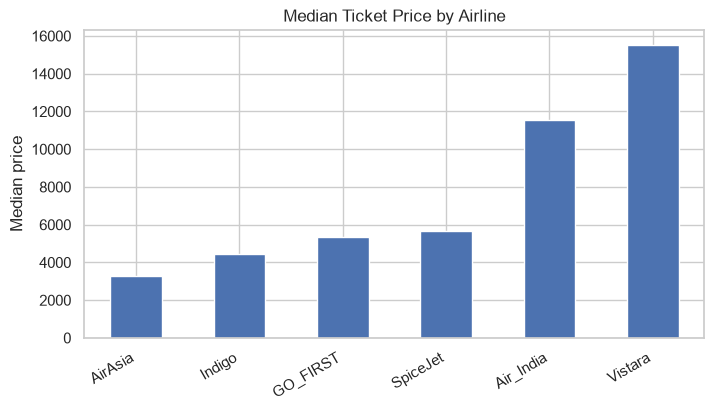

In [12]:
airline = (df.groupby("airline")["price"]
             .agg(count="size", mean="mean", median="median")
             .sort_values("median"))
display(airline)

fig, ax = plt.subplots(figsize=(8, 4))
airline["median"].plot(kind="bar", ax=ax)
ax.set_title("Median Ticket Price by Airline")
ax.set_ylabel("Median price")
ax.set_xlabel("")
plt.xticks(rotation=30, ha="right")
plt.show()


Pemisahan berdasarkan kelas untuk mengecek apakah ada impact terhadap mean atau median.

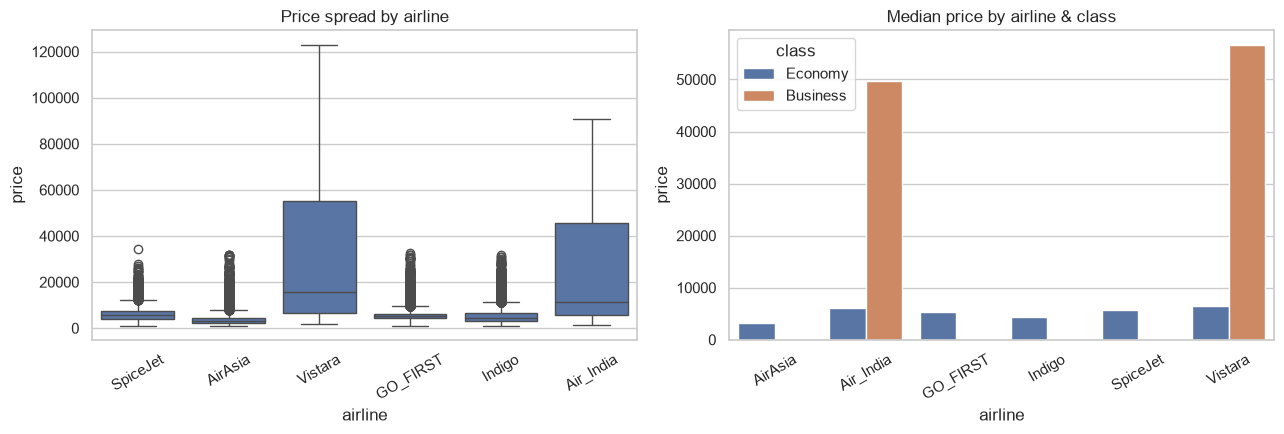

class      Business  Economy
airline                     
Vistara     56588.0   6461.0
Air_India   49613.0   6082.0
SpiceJet        NaN   5654.0
GO_FIRST        NaN   5336.0
Indigo          NaN   4453.0
AirAsia         NaN   3276.0

Market share (%):
airline
Vistara      42.6
Air_India    27.0
Indigo       14.4
GO_FIRST      7.7
AirAsia       5.4
SpiceJet      3.0
Name: proportion, dtype: float64


In [13]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(data=df, x="airline", y="price", color="#4C72B0", ax=ax[0])
ax[0].set_title("Price spread by airline")
ax[0].tick_params(axis="x", rotation=30)

med = (df.groupby(["airline", "class"], observed=True)["price"]
         .median().round(0).reset_index())
sns.barplot(data=med, x="airline", y="price", hue="class", ax=ax[1])
ax[1].set_title("Median price by airline & class")
ax[1].tick_params(axis="x", rotation=30)

plt.tight_layout(); plt.show()
print(med.pivot(index="airline", columns="class", values="price")
          .sort_values("Economy", ascending=False))
print("\nMarket share (%):")
print((df["airline"].value_counts(normalize=True) * 100).round(1))

Pengecekan price by class:

,count,mean,median,min,max
class,,,,,
Business,93487,52540.0,53164.0,12000,123071
Economy,206666,6572.0,5772.0,1105,42349


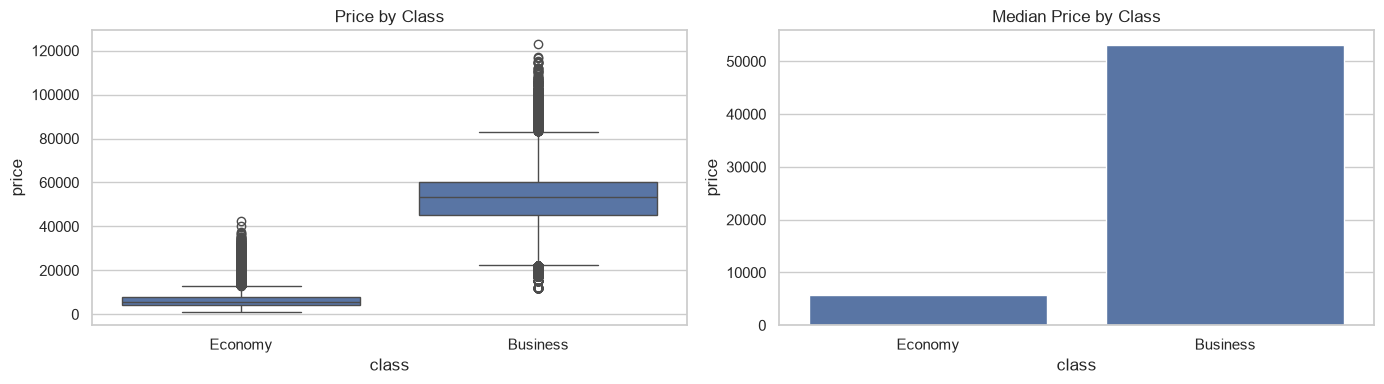

In [27]:
display(df.groupby("class")["price"].agg(["count", "mean", "median", "min", "max"]).round(0))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=df, x="class", y="price", ax=axes[0])
axes[0].set_title("Price by Class")
sns.barplot(data=df, x="class", y="price", estimator="median", ax=axes[1])
axes[1].set_title("Median Price by Class")
plt.tight_layout()
plt.show()

Melihat market share secara grafis.

,market_share_pct
airline,
Vistara,42.60
Air_India,26.95
Indigo,14.37
GO_FIRST,7.72
AirAsia,5.36
SpiceJet,3.00


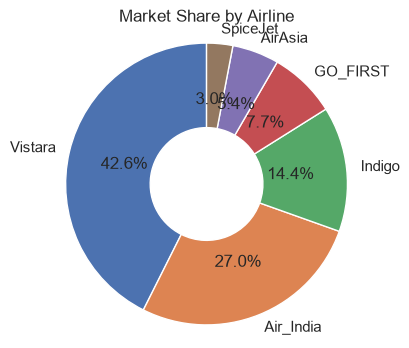

In [22]:
airline_share = (
    df["airline"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

display(airline_share.to_frame("market_share_pct"))

fig, ax = plt.subplots(figsize=(4, 4))
ax.pie(
    airline_share.values,
    labels=airline_share.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.60}
)
ax.set_title("Market Share by Airline")
ax.axis("equal")
plt.show()


**Insight:** Berdasarkan statistik dan plot grafik diatas, harga tiket memang bervariasi menurut maskapai, dan selisihnya besar. Median harga keseluruhan Vistara sebesar 15.543 INR, sekitar 4,7 kali median AirAsia yang hanya 3.276 INR. Namun, angka ini tidak sepenuhnya mencerminkan perbedaan antarmaskapai. Kelas Business hanya diterbangkan oleh Vistara dan Air India, dua maskapai yang menguasai 69,6% pasar. Akibatnya, median keseluruhan keduanya terdongkrak oleh tiket Business yang mahal, bukan hanya oleh harga maskapainya.

Agar perbandingan adil, kelas Business dipisahkan dan hanya kelas Economy yang dibandingkan. Hasilnya, Vistara tetap mematok harga sekitar 2 kali harga AirAsia untuk kursi yang sebanding. Artinya, selisih harga antarmaskapai tetap ada meskipun pengaruh kelas kabin sudah dikeluarkan.

### D.5 Q2: Apakah Harga Berubah Menurut Waktu Keberangkatan / Kedatangan?

Analisis median harga yang dihitung untuk setiap kelompok waktu, mulai dari *Early_Morning* sampai *Late_Night*, dengan waktu keberangkatan dan waktu kedatangan dianalisis secara terpisah. Setelah itu, kedua waktu digabungkan dalam satu heatmap untuk melihat kombinasi jam keberangkatan dan kedatangan mana yang paling mahal dan paling murah.

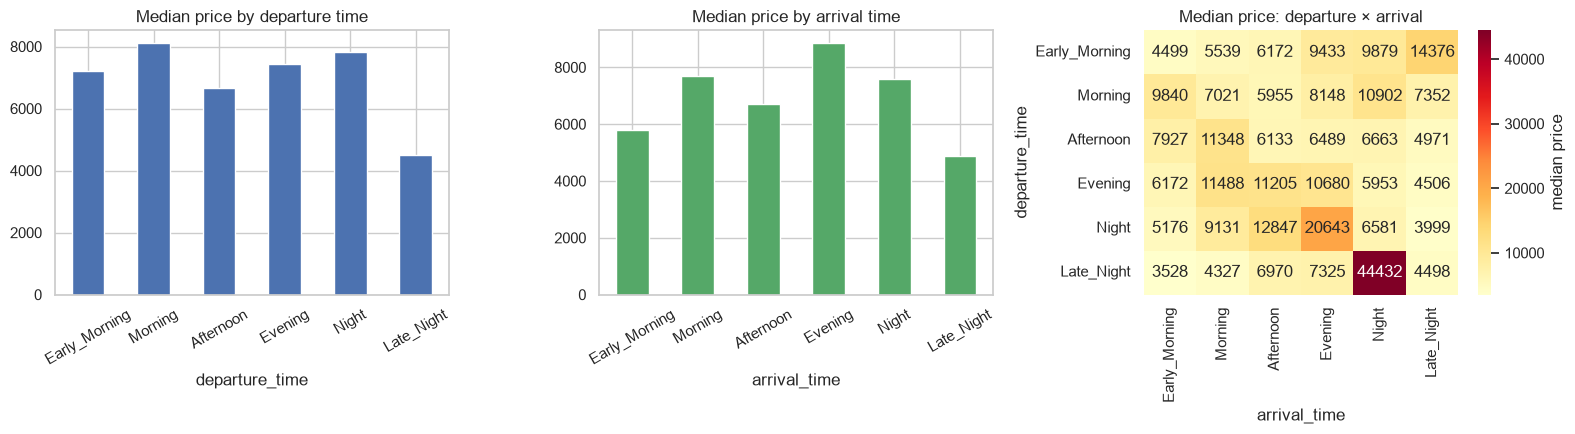

Priciest combo : ('Late_Night', 'Night') = 44,432
Cheapest combo : ('Late_Night', 'Early_Morning') = 3,528


In [5]:
time_order = ["Early_Morning", "Morning", "Afternoon", "Evening", "Night", "Late_Night"]
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

dep = df.groupby("departure_time")["price"].median().reindex(time_order)
arr = df.groupby("arrival_time")["price"].median().reindex(time_order)
dep.plot(kind="bar", ax=ax[0], color="#4C72B0", title="Median price by departure time")
arr.plot(kind="bar", ax=ax[1], color="#55A868", title="Median price by arrival time")
for a in ax[:2]:
    a.tick_params(axis="x", rotation=30)

pivot = (df.pivot_table(index="departure_time", columns="arrival_time",
                        values="price", aggfunc="median")
           .reindex(index=time_order, columns=time_order))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax[2],
            cbar_kws={"label": "median price"})
ax[2].set_title("Median price: departure × arrival")

plt.tight_layout(); plt.show()
print(f"Priciest combo : {pivot.stack().idxmax()} = {pivot.stack().max():,.0f}")
print(f"Cheapest combo : {pivot.stack().idxmin()} = {pivot.stack().min():,.0f}")

**Insight:** Berdasarkan hasil analisis, harga tiket memang berubah menurut waktu keberangkatan dan waktu kedatangan.

Dari sisi keberangkatan, penerbangan pagi memiliki median harga tertinggi, yaitu 8.112 INR, sedangkan penerbangan Late_Night paling murah dengan median 4.499 INR. Selisih keduanya sekitar 1,8 kali. Dari sisi kedatangan, kedatangan malam (Evening) memiliki median tertinggi sebesar 8.854 INR, sedangkan kedatangan Late_Night paling rendah dengan 4.867 INR.

Perbedaan yang lebih tajam terlihat pada heatmap yang menggabungkan kedua waktu. Kombinasi keberangkatan Late_Night dengan kedatangan Night memiliki median 44.432 INR, karena kombinasi ini didominasi tiket kelas Business. Sebaliknya, kombinasi keberangkatan Late_Night dengan kedatangan Early_Morning hanya bermedian 3.528 INR.

Secara umum, jam terbang yang nyaman cenderung lebih mahal, sedangkan jam terbang tengah malam cenderung lebih murah.

### D.6 Q3: Apakah Harga Berubah Menurut Kota Asal / Tujuan?

Mengurutkan kota berdasarkan median harga untuk asal dan tujuan secara terpisah, lalu membandingkan 5 rute termurah dengan 5 termahal untuk memperlihatkan sebaran pasangan kota yang sesungguhnya.

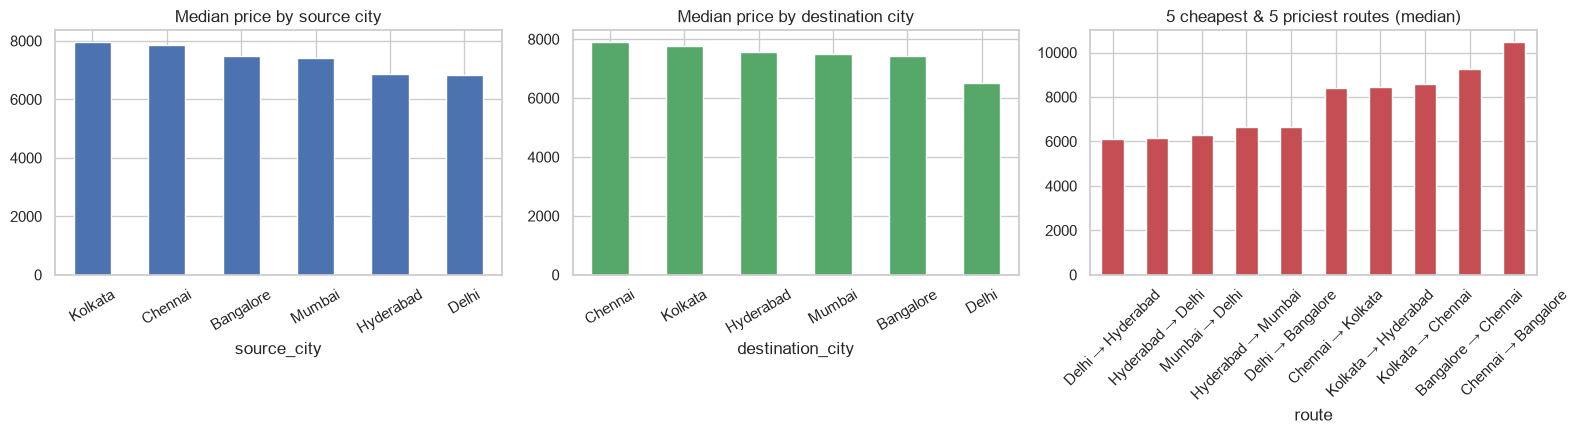

Cheapest route : Delhi → Hyderabad  (median 6,109)
Priciest route : Chennai → Bangalore (median 10,469)


In [6]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

src = df.groupby("source_city")["price"].median().sort_values(ascending=False)
dst = df.groupby("destination_city")["price"].median().sort_values(ascending=False)
src.plot(kind="bar", ax=ax[0], color="#4C72B0", title="Median price by source city")
dst.plot(kind="bar", ax=ax[1], color="#55A868", title="Median price by destination city")
for a in ax[:2]:
    a.tick_params(axis="x", rotation=30)

routes = (df.assign(route=df["source_city"] + " → " + df["destination_city"])
            .groupby("route")["price"].median().sort_values())
routes.iloc[np.r_[0:5, -5:0]].plot(kind="bar", ax=ax[2], color="#C44E52",
                                   title="5 cheapest & 5 priciest routes (median)")
ax[2].tick_params(axis="x", rotation=45)

plt.tight_layout(); plt.show()
print(f"Cheapest route : {routes.index[0]}  (median {routes.iloc[0]:,.0f})")
print(f"Priciest route : {routes.index[-1]} (median {routes.iloc[-1]:,.0f})")

**Insight:** Berdasarkan hasil analisis, harga tiket memang berubah menurut kota asal dan kota tujuan, tetapi pengaruhnya relatif kecil.

Median harga antarkota berada dalam rentang yang sempit. Menurut kota asal, median berkisar antara 6.840 dan 7.958 INR. Menurut kota tujuan, median berkisar antara 6.521 dan 7.900 INR. Delhi menjadi kota tujuan dengan median terendah, yaitu 6.521 INR.

Perbedaan lebih besar terlihat ketika kota asal dan kota tujuan digabung menjadi rute. Rute Chennai ke Bangalore memiliki median tertinggi sebesar 10.469 INR, sedangkan rute Delhi ke Hyderabad paling murah dengan median 6.109 INR. Selisih keduanya sekitar 1,7 kali.

Meskipun ada, pengaruh kota dan rute jauh lebih kecil dibandingkan pengaruh maskapai, kelas kabin, dan jendela pemesanan.

### D.7 Q4: Apakah Tiket yang Dibeli 1–2 Hari Sebelum Keberangkatan Lebih Mahal?

Analisis median harga terhadap `days_left` (1–49), dengan mengelompokan pemesanan ke dalam jendela (1–2, 3–7, 8–14, 15–30, 31–49 hari), dan kuantifikasi premium last-minute dibanding pembelian awal.

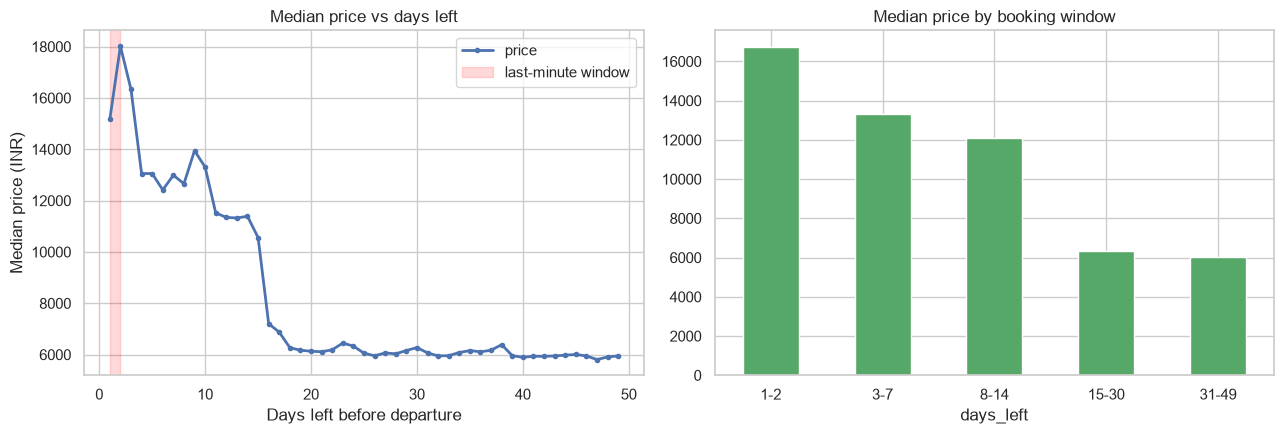

Last-minute (1-2 days) median : 16,739 INR
Advance (15+ days)    median : 6,158 INR
Last-minute premium           : 2.7x


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

trend = df.groupby("days_left")["price"].median()
trend.plot(ax=ax[0], color="#4C72B0", lw=2, marker="o", ms=3)
ax[0].axvspan(1, 2, color="red", alpha=0.15, label="last-minute window")
ax[0].set(title="Median price vs days left",
          xlabel="Days left before departure", ylabel="Median price (INR)")
ax[0].legend()

buckets = pd.cut(df["days_left"], bins=[0, 2, 7, 14, 30, 49],
                 labels=["1-2", "3-7", "8-14", "15-30", "31-49"])
window = df.groupby(buckets, observed=True)["price"].median()
window.plot(kind="bar", ax=ax[1], color="#55A868",
            title="Median price by booking window")
ax[1].tick_params(axis="x", rotation=0)

plt.tight_layout(); plt.show()

lastmin = df.loc[df["days_left"] <= 2, "price"].median()
advance = df.loc[df["days_left"] >= 15, "price"].median()
print(f"Last-minute (1-2 days) median : {lastmin:,.0f} INR")
print(f"Advance (15+ days)    median : {advance:,.0f} INR")
print(f"Last-minute premium           : {lastmin / advance:.1f}x")

**Insight:** Berdasarkan hasil analisis, harga tiket dipengaruhi oleh waktu pembelian, dan ini merupakan pola harga terkuat dalam dataset.

Tiket yang dibeli 1 sampai 2 hari sebelum keberangkatan memiliki median harga 16.739 INR, sedangkan tiket yang dibeli 15 hari atau lebih sebelumnya hanya bermedian 6.158 INR. Artinya, pembeli menit terakhir membayar sekitar 2,7 kali lebih mahal.

Harga turun tajam seiring semakin panjangnya jarak pembelian dari hari keberangkatan, lalu mendatar di sekitar 6.000 INR mulai dua minggu sebelum keberangkatan. Membeli lebih awal dari 15 hari hampir tidak memberikan penghematan tambahan. Puncak harga justru terjadi pada 2 hari sebelum keberangkatan dengan median 18.018 INR, lebih tinggi daripada 1 hari sebelum keberangkatan.

Dengan demikian, waktu pembelian yang paling hemat biaya dimulai sekitar 15 hari sebelum keberangkatan.

### D.8 Analisis Variable Sekunder Yang Mendorong Harga: Transit, Durasi, Kelas

Melihat variable data lain yang memungkinkan mempunyai pengaruh tidak langsung terhadap harga.

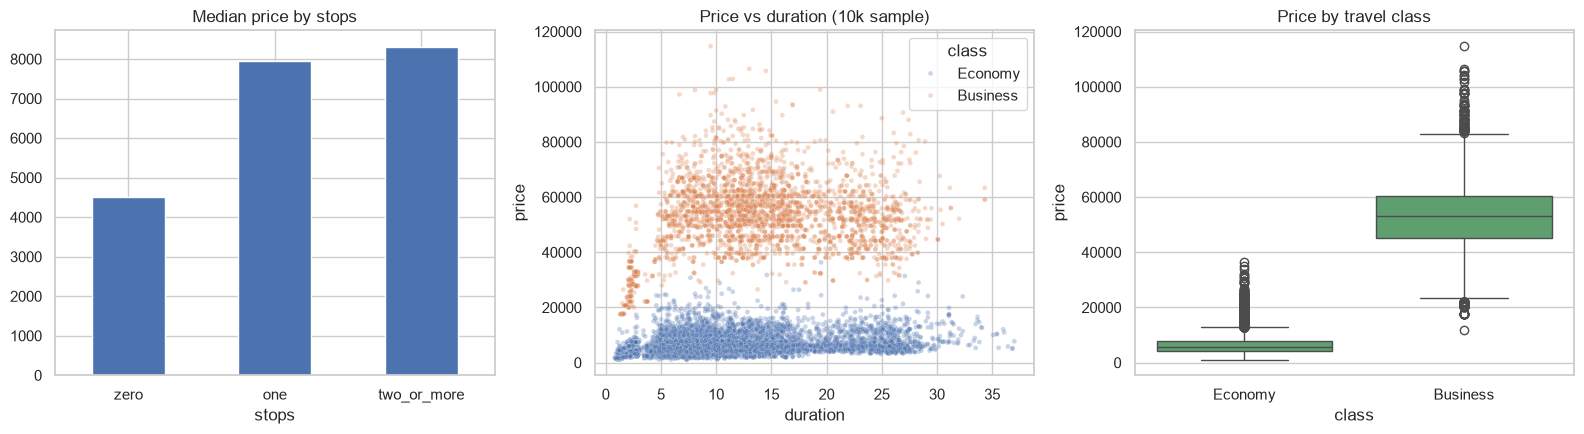

Duration-price correlation (all)     : 0.204
Duration-price correlation (Economy)  : 0.288
Duration-price correlation (Business) : 0.243

Class medians : {'Business': 53164.0, 'Economy': 5772.0}
Stops share % : {'one': 83.6, 'zero': 12.0, 'two_or_more': 4.4}


In [8]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

stops = df.groupby("stops")["price"].median().reindex(["zero", "one", "two_or_more"])
stops.plot(kind="bar", ax=ax[0], color="#4C72B0", title="Median price by stops")
ax[0].tick_params(axis="x", rotation=0)

sns.scatterplot(data=df.sample(10000, random_state=42), x="duration", y="price",
                hue="class", alpha=0.3, s=12, ax=ax[1])
ax[1].set_title("Price vs duration (10k sample)")

sns.boxplot(data=df.sample(20000, random_state=42), x="class", y="price",
            color="#55A868", ax=ax[2])
ax[2].set_title("Price by travel class")

plt.tight_layout(); plt.show()

eco = df["class"] == "Economy"
print(f"Duration-price correlation (all)     : {df['duration'].corr(df['price']):.3f}")
print(f"Duration-price correlation (Economy)  : {df.loc[eco, 'duration'].corr(df.loc[eco, 'price']):.3f}")
print(f"Duration-price correlation (Business) : {df.loc[~eco, 'duration'].corr(df.loc[~eco, 'price']):.3f}")
print(f"\nClass medians : {df.groupby('class')['price'].median().round(0).to_dict()}")
print(f"Stops share % : {(df['stops'].value_counts(normalize=True) * 100).round(1).to_dict()}")

**Insight:** Berdasarkan hasil analisis, tiga variabel sekunder yang diuji, yaitu jumlah transit, durasi, dan kelas kabin, punya pengaruh yang berbeda jauh terhadap harga.

- **Transit.** Penerbangan langsung (tanpa transit) mempunyai harga paling murah, dengan median 4.499 INR. Penerbangan dengan sekali transit dengan median 7.959 INR, sekitar 1,77 kali lebih mahal. Penerbangan sekali transit juga mendominasi pasar, yaitu 83,6% dari seluruh data.

- **Durasi.** Hubungan durasi dengan harga lemah, Kkoefisien korelasinya 0,20 pada seluruh data dan 0,29 pada kelas Economy. Penerbangan yang lebih lama tidak otomatis lebih mahal.

- **Kelas kabin.** Kelas adalah faktor dengan pengaruh terbesar, nilai median untuk tiket Business sebesar 53.164 INR, sedangkan Economy 5.772 INR, selisih sekitar 9,2 kali.

Berdasarkan besar pengaruhnya, urutan faktor pendorong harga adalah:
1. Kelas kabin (sekitar 9,2 kali)
2. Jendela pemesanan (sekitar 2,7 kali)
3. Maskapai (sekitar 2 kali pada kelas Economy)
4. Waktu penerbangan (sekitar 1,8 kali)
5. Jumlah transit (sekitar 1,77 kali)
6. Rute (sekitar 1,7 kali)
7. Durasi (lemah)

### D.9 Pre-Processing dan Features Engineering

Pada bagian ini, setiap langkah bertujuan memastikan data siap digunakan untuk pemodelan.

1. **Nilai kosong dan duplikat.** Data mentah diperiksa ulang karena data masukan model perlu diverifikasi secara terpisah dari tahap EDA.
2. **Audit outlier dengan metode IQR.** Titik data di luar 1,5 kali IQR pada `price` dan `duration` ditandai, tetapi tidak dihapus. Harga yang ekstrem dapat berasal dari tarif Business yang sah. Menghapus harga pasar yang valid akan membuat model bias terhadap segmen premium.
3. **Pengubahan tipe data.** Tujuh kolom kategorikal diubah ke tipe `category` pada pandas agar semantiknya tepat dan penggunaan memori berkurang secara signifikan.
4. **Pemilihan fitur.** Kolom `flight` dibuang karena memiliki 1.561 kode unik. Kolom berkardinalitas tinggi seperti ini nyaris menyebabkan kebocoran data dan tidak dapat digeneralisasi ke penerbangan yang belum pernah dilihat model. Sembilan prediktor dipertahankan.
5. **Transformasi target.** Distribusi harga miring ke kanan (skewness +1,06), sehingga model dilatih pada `log1p(price)`. Hasil prediksi dikembalikan ke skala asli dengan `expm1`.
6. **Pengkodean fitur.** Fitur kategorikal dikodekan dengan one hot encoding (35 kolom), sedangkan `duration` dan `days_left` distandarisasi. Standarisasi diperlukan oleh model linear dan tidak memengaruhi model berbasis pohon. Hasilnya 37 fitur model. Interaksi rute tidak perlu dibuat secara eksplisit karena model berbasis pohon mempelajari interaksi `source_city` dan `destination_city` melalui percabangannya.
7. **Pembagian data.** Data dibagi menjadi 80% data latih dan 20% data uji dengan `random_state=42`. Pengkodean dijalankan di dalam `Pipeline` sklearn sehingga hanya dipelajari dari data latih, sehingga tidak terjadi kebocoran data.

In [ ]:
# --- 1. Missing values & duplicates -------------------------------------
print(f"Missing values : {df.isna().sum().sum()}")
print(f"Duplicate rows : {df.duplicated().sum()}")

# --- 2. Outlier audit (IQR method) ---------------------------------------
for c in ["price", "duration"]:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = int(((df[c] < lo) | (df[c] > hi)).sum())
    print(f"{c:9s}: IQR bounds [{lo:,.0f}, {hi:,.0f}] -> {n} outliers "
          f"({n / len(df) * 100:.2f}%)")

# --- 3. Type casting: object -> category ----------------------------------
cat_cols = ["airline", "source_city", "departure_time", "stops",
            "arrival_time", "destination_city", "class"]
mem_before = df.memory_usage(deep=True).sum() / 1e6
df[cat_cols] = df[cat_cols].astype("category")
mem_after = df.memory_usage(deep=True).sum() / 1e6
print(f"\nMemory: {mem_before:.0f} MB -> {mem_after:.0f} MB "
      f"({mem_after / mem_before * 100:.0f}%) after category casting")

# --- 4. Feature selection -------------------------------------------------
X = df.drop(columns=["price", "flight"])   # drop flight, no generalization
y = np.log1p(df["price"])                  # 5. target: log1p(price)

# --- 6. Encoding inside a Pipeline (fit on train only -> no leakage) ------
preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ("num", StandardScaler(), ["duration", "days_left"]),
])

# --- 7. Train/test split ---------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f"\nTrain: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")
print(f"Model features after encoding: {preprocess.fit(X_train).transform(X_train).shape[1]}")
print(f"Target skew: raw {df['price'].skew():.2f} -> log1p {y.skew():.2f}")

Missing values : 0
Duplicate rows : 0
price    : IQR bounds [-51,824, 99,128] -> 123 outliers (0.04%)
duration : IQR bounds [-7, 30] -> 2110 outliers (0.70%)

Memory: 141 MB -> 26 MB (18%) after category casting

Train: 240,122 rows | Test: 60,031 rows
Model features after encoding: 37
Target skew: raw 1.06 -> log1p 0.40


Data masukan untuk pemodelan berada dalam kondisi baik, tanpa missing values dan tanpa duplikat. Audit IQR menandai 123 outlier pada harga (0,04%) dan 2.110 outlier pada durasi (0,70%). Keduanya tetap dipertahankan karena merupakan nilai pasar yang sah, yaitu tarif Business dan rute multi-transit yang panjang, bukan kesalahan data.

Kolom `flight` dibuang karena memiliki 1.561 kode unik yang tidak dapat digeneralisasi ke penerbangan yang belum pernah dilihat model. Transformasi `log1p(price)` menurunkan skewness dari +1,06 menjadi +0,41.

### D.10 Pemilihan Model dan Algoritma

Lima model regresi dilatih pada data yang sama, dengan kompleksitas yang meningkat bertahap: Linear Regression sebagai baseline, Ridge sebagai model linear dengan regularisasi, Decision Tree sebagai model nonlinear, Random Forest sebagai ensemble bagging, dan HistGradientBoosting sebagai ensemble boosting.

Setiap model dievaluasi pada data uji dengan dua cara. Pertama, R² dan MAE pada skala log, yaitu skala yang dioptimalkan model. Kedua, metrik pada skala INR, yang lebih relevan bagi bisnis. MAPE ikut dihitung karena tidak bergantung pada skala harga, sehingga hasilnya bisa dibandingkan antara kelas Economy dan Business.

                      R2 (log)  R2 (INR)  MAE (INR)  RMSE (INR)  MAPE (%)  Fit (s)
Model                                                                             
Linear Regression       0.9162    0.8820     4573.0      7798.0   26.0407      1.0
Ridge (alpha=1)         0.9162    0.8821     4573.0      7797.0   26.0408      0.0
Decision Tree           0.9773    0.9757     1163.0      3537.0    7.1549      2.0
Random Forest           0.9861    0.9851     1051.0      2773.0    6.3635     12.0
HistGradientBoosting    0.9663    0.9618     2489.0      4436.0   14.9747      2.0

Best model: Random Forest (R2 = 0.9851)


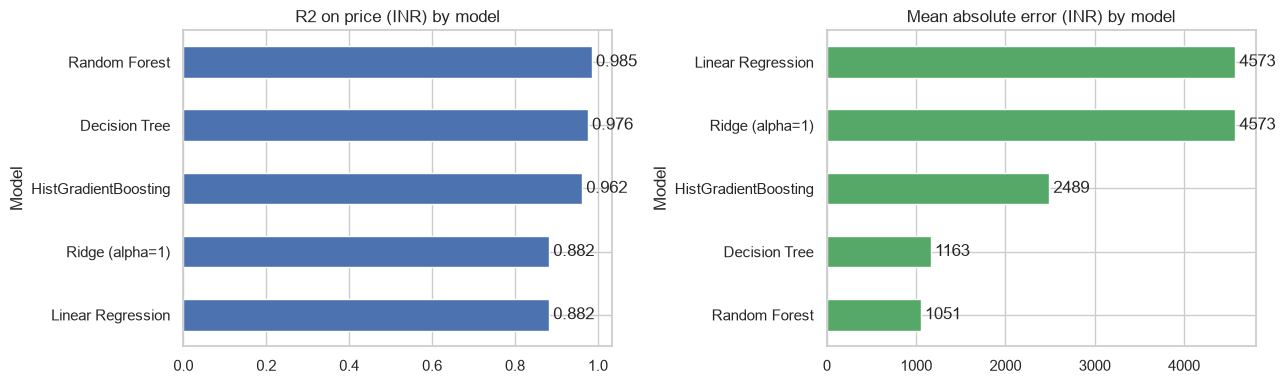

In [10]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge (alpha=1)": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, n_jobs=-1,
                                           random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42),
}

y_test_price = np.expm1(y_test)          # ground truth in INR
results = []

for name, model in models.items():
    t0 = time.time()
    pipe = Pipeline([("pre", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    fit_s = time.time() - t0

    pred_log = pipe.predict(X_test)
    pred_price = np.expm1(np.clip(pred_log, 0, None))   # back to INR

    results.append({
        "Model": name,
        "R2 (log)": r2_score(y_test, pred_log),
        "R2 (INR)": r2_score(y_test_price, pred_price),
        "MAE (INR)": mean_absolute_error(y_test_price, pred_price),
        "RMSE (INR)": np.sqrt(mean_squared_error(y_test_price, pred_price)),
        "MAPE (%)": np.mean(np.abs((y_test_price - pred_price) / y_test_price)) * 100,
        "Fit (s)": fit_s,
    })

res_df = pd.DataFrame(results).set_index("Model").round(4)
res_df[["MAE (INR)", "RMSE (INR)", "Fit (s)"]] = res_df[["MAE (INR)", "RMSE (INR)", "Fit (s)"]].round(0)
print(res_df.to_string())

best_row = res_df["R2 (INR)"].idxmax()
print(f"\nBest model: {best_row} (R2 = {res_df.loc[best_row, 'R2 (INR)']:.4f})")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
res_df["R2 (INR)"].sort_values().plot(kind="barh", ax=ax[0], color="#4C72B0",
                                     title="R2 on price (INR) by model")
res_df["MAE (INR)"].sort_values().plot(kind="barh", ax=ax[1], color="#55A868",
                                       title="Mean absolute error (INR) by model")
for a in ax:
    a.bar_label(a.containers[0], fmt="%.3f" if a is ax[0] else "%.0f", padding=3)
plt.tight_layout(); plt.show()

Random Forest memberikan hasil terbaik dengan R² 0,985 pada skala INR, MAE 1.051 INR, dan MAPE 6,4%.

Model linear hanya mencapai R² 0,88 dengan MAE sekitar 4.573 INR, karena harga dipengaruhi interaksi nonlinear antara kelas, maskapai, dan `days_left` yang tidak dapat ditangkap model linear. Satu Decision Tree sudah mencapai R² 0,976, dan penggabungan 100 pohon pada Random Forest menaikkannya ke 0,985 serta menurunkan MAE sekitar 10%. HistGradientBoosting dengan pengaturan default mencapai R² 0,962, sehingga memerlukan tuning untuk menyaingi Random Forest.

Waktu pelatihan Random Forest sekitar 13 detik pada 240 ribu baris data, sehingga tuning lanjutan masih terjangkau.

### D.11 Tuning Hyperparameter (Random Forest)

Tahapan ini dilakukan untuk menguji apakah model dapat dilakukan improvement secara akurasinya. Dua hyperparameter yang paling berpengaruh pada Random Forest adalah `n_estimators` (jumlah pohon) dan `max_depth` (kedalaman pohon). Tuning dilakukan dengan grid kecil yang dibatasi waktu, yaitu 100 dan 150 pohon dengan kedalaman tanpa batas, 20, dan 25. Konfigurasi terbaik dipilih berdasarkan R² pada data uji dalam skala INR.

`GridSearchCV` penuh dengan 5-fold cross validation tidak digunakan karena membutuhkan komputasi sekitar 15 kali lebih besar, sedangkan peningkatan hasilnya diperkirakan kecil untuk ukuran dataset ini.

In [11]:
configs = [(100, None), (150, None), (100, 20), (150, 25)]
tune_rows = []

for n_est, depth in configs:
    t0 = time.time()
    pipe = Pipeline([("pre", preprocess),
                     ("model", RandomForestRegressor(n_estimators=n_est,
                                                     max_depth=depth,
                                                     n_jobs=-1, random_state=42))])
    pipe.fit(X_train, y_train)
    pred_price = np.expm1(np.clip(pipe.predict(X_test), 0, None))
    tune_rows.append({
        "n_estimators": n_est, "max_depth": depth or "None",
        "R2 (INR)": r2_score(y_test_price, pred_price),
        "MAE (INR)": mean_absolute_error(y_test_price, pred_price),
        "Fit (s)": time.time() - t0,
    })

tune_df = pd.DataFrame(tune_rows).round(4)
tune_df[["MAE (INR)", "Fit (s)"]] = tune_df[["MAE (INR)", "Fit (s)"]].round(0)
print(tune_df.to_string(index=False))

best_cfg = tune_df.loc[tune_df["R2 (INR)"].idxmax()]
print(f"\nSelected: n_estimators={best_cfg['n_estimators']}, "
      f"max_depth={best_cfg['max_depth']} "
      f"(R2={best_cfg['R2 (INR)']:.4f}, MAE={best_cfg['MAE (INR)']:.0f} INR)")

 n_estimators max_depth  R2 (INR)  MAE (INR)  Fit (s)
          100      None    0.9851     1051.0     22.0
          150      None    0.9851     1050.0     50.0
          100        20    0.9845     1279.0     27.0
          150        25    0.9854     1089.0     40.0

Selected: n_estimators=150, max_depth=25 (R2=0.9854, MAE=1089 INR)


Hasil tuning menunjukkan hyperparameter hampir tidak memengaruhi performa. Keempat konfigurasi yang dilaporkan hanya berbeda sekitar 0,001 pada R². Konfigurasi dengan R² tertinggi adalah 150 pohon dengan kedalaman 25 (0,9854), tetapi MAE-nya 1.089 INR, lebih buruk daripada konfigurasi default yang mencapai 1.051 INR. Menambah pohon dari 100 menjadi 150 pada kedalaman tanpa batas tidak mengubah R² (0,9851 pada keduanya), sehingga ensemble tampaknya sudah konvergen. Membatasi kedalaman pada 20 menurunkan performa: R² turun menjadi 0,9845 dan MAE naik menjadi 1.279 INR, karena pohon yang dalam diperlukan untuk menangkap interaksi antarfitur.

Konfigurasi default dipertahankan, yaitu `n_estimators=100` dan `max_depth=None`. Konfigurasi ini memiliki MAE terbaik, R² yang hampir sama dengan yang tertinggi, dan waktu pelatihan paling singkat. Selisih R² 0,0003 dari konfigurasi 150 pohon dengan kedalaman 25 terlalu kecil untuk dianggap peningkatan nyata.

### D.12 Model Final: Evaluasi dan Interpretasi

Random Forest dengan hyperparameter terpilih dilatih ulang, lalu dievaluasi dengan tiga cara.

1. **Scatter plot prediksi terhadap nilai aktual** untuk memeriksa kecocokan prediksi secara keseluruhan.
2. **Analisis residual** untuk mendeteksi bias yang konsisten pada berbagai rentang harga dan kelas kabin.
3. **Feature importance** dengan dua metode. Metode berbasis impurity dihitung cepat, tetapi cenderung bias terhadap fitur dengan banyak nilai unik. Permutation importance tidak bergantung pada jenis model dan diukur dari penurunan R² ketika nilai satu fitur diacak, sehingga hasilnya lebih dapat diandalkan.

Final Random Forest — test performance (n = 60,031)
  R2   : 0.9851
  MAE  : 1,051 INR
  RMSE : 2,773 INR
  MAPE : 6.4%


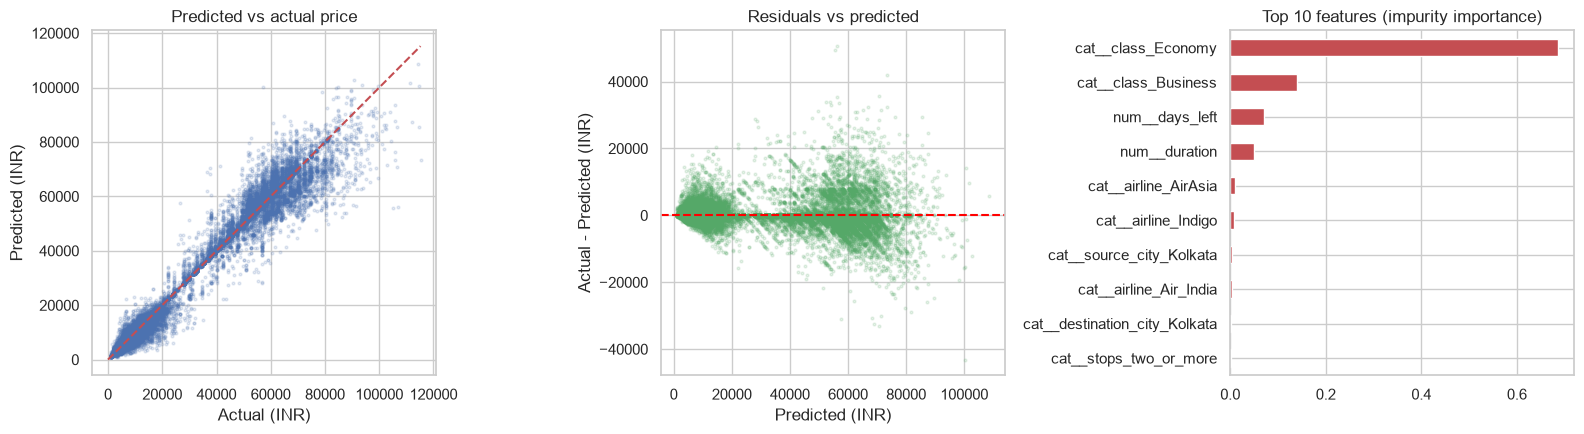


Permutation importance (R2 drop on log target):
class               1.5530
days_left           0.1520
duration            0.1044
airline             0.0807
source_city         0.0428
destination_city    0.0373
arrival_time        0.0126
departure_time      0.0092
stops               0.0075

MAE by class  — Economy: 569 INR | Business: 2,114 INR
Residual mean: 70 INR | 5th-95th pct: [-2,565, 3,446]


In [12]:
# --- Final model: tuned Random Forest -----------------------------------
final_model = Pipeline([
    ("pre", preprocess),
    ("model", RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)),
])
final_model.fit(X_train, y_train)

pred_log = final_model.predict(X_test)
pred_price = np.expm1(np.clip(pred_log, 0, None))
residual = y_test_price - pred_price

print(f"Final Random Forest — test performance (n = {len(y_test):,})")
print(f"  R2   : {r2_score(y_test_price, pred_price):.4f}")
print(f"  MAE  : {mean_absolute_error(y_test_price, pred_price):,.0f} INR")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test_price, pred_price)):,.0f} INR")
print(f"  MAPE : {np.mean(np.abs(residual / y_test_price)) * 100:.1f}%")

# --- 1. Predicted vs actual ----------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

ax[0].scatter(y_test_price, pred_price, s=4, alpha=0.15, color="#4C72B0")
lim = [0, y_test_price.max()]
ax[0].plot(lim, lim, "r--", lw=1.5)
ax[0].set(title="Predicted vs actual price", xlabel="Actual (INR)",
          ylabel="Predicted (INR)")

# --- 2. Residuals ---------------------------------------------------------
ax[1].scatter(pred_price, residual, s=4, alpha=0.15, color="#55A868")
ax[1].axhline(0, color="red", ls="--", lw=1.5)
ax[1].set(title="Residuals vs predicted", xlabel="Predicted (INR)",
          ylabel="Actual - Predicted (INR)")

# --- 3. Feature importance (impurity-based) ------------------------------
names = final_model.named_steps["pre"].get_feature_names_out()
imp = final_model.named_steps["model"].feature_importances_
top = pd.Series(imp, index=names).nlargest(10).sort_values()
top.plot(kind="barh", ax=ax[2], color="#C44E52",
         title="Top 10 features (impurity importance)")

plt.tight_layout(); plt.show()

# --- Permutation importance (model-agnostic) -----------------------------
rng = np.random.RandomState(42)
idx = rng.choice(len(X_test), 10000, replace=False)
perm = permutation_importance(final_model, X_test.iloc[idx], y_test.iloc[idx],
                              n_repeats=5, random_state=42, n_jobs=-1)
perm_s = pd.Series(perm.importances_mean, index=X.columns).sort_values()
print("\nPermutation importance (R2 drop on log target):")
print(perm_s.sort_values(ascending=False).round(4).to_string())

print(f"\nMAE by class  — Economy: "
      f"{mean_absolute_error(y_test_price[X_test['class'] == 'Economy'], pred_price[X_test['class'] == 'Economy']):,.0f} INR"
      f" | Business: "
      f"{mean_absolute_error(y_test_price[X_test['class'] == 'Business'], pred_price[X_test['class'] == 'Business']):,.0f} INR")
print(f"Residual mean: {residual.mean():,.0f} INR | "
      f"5th-95th pct: [{np.quantile(residual, 0.05):,.0f}, {np.quantile(residual, 0.95):,.0f}]")

## E. Findings

### E.1 Rangkuman dari 4 pertanyaan yang ingin dianalisis

| Pertanyaan | Jawaban | Bukti |
|---|---|---|
| (a) Apakah harga bervariasi menurut maskapai? | **Ya** | Median keseluruhan Vistara sekitar 4,7 kali AirAsia, dan sekitar 2 kali pada kelas Economy |
| (b) Apakah harga bervariasi menurut waktu keberangkatan dan kedatangan? | **Ya** | Median keberangkatan pagi sekitar 1,8 kali keberangkatan Late_Night, dan kedatangan Evening paling mahal |
| (c) Apakah harga bervariasi menurut kota asal dan tujuan? | **Ya, tetapi kecil** | Median rute berbeda sekitar 1,7 kali antara Chennai ke Bangalore dan Delhi ke Hyderabad |
| (d) Apakah tiket yang dibeli mepet lebih mahal? | **Ya, sangat** | Pembelian 1 sampai 2 hari sebelum keberangkatan sekitar 2,7 kali lebih mahal daripada pembelian 15 hari atau lebih |

### E.2 Urutan Faktor Pendorong Harga

Berdasarkan besar pengaruhnya, urutan faktor adalah kelas kabin (9,2 kali), jendela pemesanan (2,7 kali), maskapai (sekitar 2 kali pada kelas Economy), waktu penerbangan (1,8 kali), jumlah transit (1,77 kali), rute (1,7 kali), dan durasi (lemah, r = 0,20).

Kelas kabin adalah faktor terbesar. Median tiket Business sebesar 53.164 INR, sedangkan Economy 5.772 INR. Jendela pemesanan berada di urutan kedua. Tiket yang dibeli 1 sampai 2 hari sebelum keberangkatan sekitar 2,7 kali lebih mahal daripada tiket yang dibeli lebih awal, dan harga mendatar di sekitar 6.000 INR mulai 15 hari sebelum keberangkatan. Perbedaan antarmaskapai tetap ada setelah kelas Business dikeluarkan, dengan harga Vistara sekitar dua kali AirAsia pada kelas Economy. Waktu, transit, dan rute memengaruhi harga dalam rentang yang lebih sempit, yaitu 1,7 sampai 1,8 kali. Durasi memiliki hubungan linear yang lemah dengan harga.

Ketiga faktor dengan rasio yang sangat berdekatan (waktu, transit, dan rute) sebaiknya tidak dibaca sebagai urutan yang pasti. Rasio ini juga membandingkan kelompok ekstrem, sedangkan durasi diukur dengan korelasi, sehingga urutan ini hanya gambaran kasar.

### E.3 Hasil Model

**Random Forest mencapai R² 0,985, MAE 1.051 INR, dan MAPE 6,4%.** Rata-rata, prediksi model menyimpang sekitar 6,4% dari tarif sebenarnya. Nilai R² ini sesuai dengan benchmark pada dokumentasi dataset.

Temuan dari proses pemodelan:

* **Hubungan harga bersifat nonlinear.** Model linear hanya mencapai R² 0,88, sedangkan Random Forest mencapai 0,985. Selisih ini menunjukkan bahwa harga dipengaruhi interaksi antara kelas, maskapai, dan `days_left` yang lebih baik ditangkap model berbasis pohon.
* **Konfigurasi default sudah memadai.** Pada grid yang diuji, R² hanya bergeser kurang dari 0,001, dan konfigurasi default dengan 100 pohon memiliki MAE terbaik. Tuning tidak memberi peningkatan berarti.
* **Feature importance sejalan dengan EDA, dengan satu perbedaan.** Permutation importance menempatkan kelas (1,55) dan `days_left` (0,15) di urutan teratas, sesuai dengan urutan pengaruh pada E.2. Perbedaannya ada pada durasi. Korelasi linearnya dengan harga lemah (r = 0,20), tetapi importance-nya sedikit di atas maskapai (0,10 dibanding 0,08). Kemungkinan model memanfaatkan durasi melalui pola nonlinear dan interaksi dengan rute yang tidak tertangkap koefisien korelasi.
* **Galat membesar pada tarif yang lebih tinggi.** Residual melebar pada tiket Business (korelasi antara |residual| dan prediksi sebesar 0,36), sehingga prediksi untuk Economy lebih akurat daripada untuk tarif premium.

### E.4 Catatan dan Keterbatasan

Hasil ini menunjukkan asosiasi pada data observasional, bukan hubungan sebab akibat. Dataset tidak memuat tanggal kalender, sehingga pengaruh musiman tidak dapat dianalisis. Pengaruh rute sebagian bercampur dengan durasi dan jumlah transit. Konfigurasi

## F. Solusi dan Rekomendasi

### F.1 Untuk Penumpang

Pesan tiket minimal 15 hari sebelum keberangkatan. Kebiasaan ini menangkap sebagian besar penghematan yang tersedia, hingga sekitar 2,7 kali lebih murah untuk rute dan kelas kabin yang sama, karena harga mendatar setelah dua minggu. Membeli lebih awal dari 15 hari hampir tidak memberi penghematan tambahan.

Ada tiga cara lain untuk menekan harga:

1. Pilih keberangkatan Late_Night atau Early_Morning, yang cenderung lebih murah daripada keberangkatan pagi.
2. Pilih penerbangan langsung bila tersedia. Penerbangan dengan sekali transit sekitar 1,77 kali lebih mahal.
3. Pertimbangkan tujuan Delhi, yang memiliki median harga terendah di antara enam kota tujuan, meskipun selisihnya dengan kota lain kecil.

### F.2 Untuk Maskapai dan Platform Pemesanan

**Atur harga secara sengaja pada jendela kurang dari dua minggu.** Harga naik tajam dari 15 hari sebelum keberangkatan hingga hari keberangkatan, dan di sinilah penetapan harga dinamis paling berperan. Median tertinggi terjadi pada 2 hari sebelum keberangkatan (18.018 INR), bahkan di atas 1 hari sebelumnya. Dua hari terakhir tampaknya menjadi periode dengan kesediaan membayar tertinggi.

**Tinjau ulang slot tengah malam.** Keberangkatan dan kedatangan Late_Night memiliki median terendah. Bila sebagian kursi diisi penumpang yang kurang sensitif terhadap harga, misalnya pebisnis dengan jadwal padat atau penumpang yang membutuhkan koneksi malam, potensi pendapatan mungkin belum tergali. Uji kenaikan harga terbatas sebelum memberi diskon lebih lanjut.

**Pantau rute Chennai ke Bangalore.** Rute ini memiliki median tertinggi, yaitu 10.469 INR, dibandingkan 6.109 INR pada rute Delhi ke Hyderabad. Selisih ini layak ditinjau oleh tim manajemen pendapatan di kedua ujung rute.

### F.3 Penerapan Model dalam Proses Bisnis

`Pipeline` yang telah dilatih dapat langsung digunakan, dengan model yang disimpan misalnya dengan nama `joblib.dump`. Model ini dapat disajikan melalui API internal. API dapat dipanggil dengan melempar variable yang dibutuhkan untuk memprediksi harga. Pipeline dan testing dapat dilakukan secara berkala untuk melatih model dengan data baru berdasrkan fakta di operasional pasar.

Tiga penggunaan yang sesuai dengan tingkat akurasi saat ini:

1. **Penasihat tarif untuk penumpang.** Sebelum membeli, penumpang mendapat perkiraan harga untuk perjalanannya. Tarif yang jauh di atas perkiraan menjadi tanda untuk menunda pembelian atau memilih slot lain, sedangkan tarif di bawah perkiraan menandakan penawaran yang baik. Dengan MAPE 6,4%, perkiraan ini berguna sebagai acuan, bukan jaminan.
2. **Penanda salah harga untuk tim pendapatan.** Model dijalankan setiap hari pada inventaris yang tersedia. Kursi dengan harga jauh di atas atau di bawah rentang prediksi ditandai untuk ditinjau, sehingga model berfungsi sebagai lapisan pemantauan di atas aturan harga yang sudah ada.
3. **Simulasi permintaan.** Karena model mempelajari pengaruh `days_left`, tim dapat memasukkan berbagai jendela pemesanan untuk melihat perubahan